# Ćw. 3 Klasyfikacja za pomocą sieci neuronowej PyTorch

## Co to jest problem klasyfikacji?

Problem klasyfikacji [classification problem](https://en.wikipedia.org/wiki/Statistical_classification) polega na przewidywaniu, czy coś jest taką czy inną rzeczą.

Na przykład, możesz chcieć:

| Typ problemu | Co to jest? | Przykład |
| ----- | ----- | ----- |
| **Klasyfikacja binarna** | Cel może być jedną z dwóch opcji, np. tak lub nie | Przewidywanie, czy ktoś ma chorobę serca na podstawie jego parametrów zdrowotnych. |
| **Klasyfikacja wieloklasowa** | Cel może być jedną z więcej niż dwóch opcji | Zdecyduj, czy zdjęcie przedstawia jedzenie, osobę czy psa. |
| **Klasyfikacja wieloetykietowa** | Celowi można przypisać więcej niż jedną opcję | Przewidywanie, jakie kategorie powinny być przypisane do artykułu Wikipedii (np. matematyka, nauka i filozofia). |

Innymi słowy, biorąc zestaw danych wejściowych i przewidując, do jakiej klasy należy ten zestaw danych wejściowych.



## Zawartość ćwiczeń

Korzystamy z Workflowu omawianego na poprzednich ćwiczeniach.


Z wyjątkiem tego, że zamiast próbować przewidzieć linię prostą (przewidywanie liczby, zwane również problemem regresji), będziemy pracować nad **problemem klasyfikacji**.

W szczególności zajmiemy się:

| **Temat** | **Zawartość** |
| ----- | ----- |
| **Architektura klasyfikacyjnej sieci neuronowej** | Sieci neuronowe mogą mieć prawie dowolny kształt lub rozmiar, ale zazwyczaj mają podobny plan działania. |
| **1. Przygotowanie danych klasyfikacji binarnej** | Dane mogą być niemal dowolne, ale na początek utworzymy prosty zbiór danych klasyfikacji binarnej. |
| **2. Budowanie modelu klasyfikacji PyTorch** | Tutaj stworzymy model do nauki wzorców w danych, wybierzemy również **funkcję straty**, **optymalizator** i zbudujemy **pętlę uczącą** specyficzną dla klasyfikacji. |
| **3. Dopasowanie modelu do danych (uczenie)** | Mamy dane i model, teraz pozwólmy modelowi (spróbować) znaleźć wzorce w danych (**treningowych**). |
| **4. Prognozowanie i ocena modelu (wnioskowanie)** | Nasz model znalazł wzorce w danych, porównajmy jego wyniki z rzeczywistymi danymi (**testowanie**). |
| **5. Ulepszanie modelu (z perspektywy modelu)** | Wytrenowaliśmy i oceniliśmy model, ale nie działa, spróbujmy kilku rzeczy, aby go ulepszyć. |
| **6. Nieliniowość** | Do tej pory nasz model był w stanie modelować tylko linie proste, a co z liniami nieliniowymi (nieprostymi)? |
| **7. Replikacja funkcji nieliniowych** | Użyliśmy **funkcji nieliniowych**, aby pomóc w modelowaniu danych nieliniowych, ale jak one wyglądają? |
| **8. Połączenie tego wszystkiego z klasyfikacją wieloklasową** | Połączmy wszystko, co zrobiliśmy do tej pory dla klasyfikacji binarnej z problemem klasyfikacji wieloklasowej. |


## 0. Architektura klasyfikacyjnej sieci neuronowej

Zanim przejdziemy do pisania kodu, przyjrzyjmy się ogólnej architekturze klasyfikacyjnej sieci neuronowej.

| **Hiperparametr** | **Klasyfikacja binarna** | **Klasyfikacja wieloklasowa** |
| --- | --- | --- |
| **Kształt warstwy wejściowej** (`in_features`) | Taki sam jak liczba cech (np. 5 dla wieku, płci, wzrostu, wagi, statusu palenia w predykcji chorób serca) | Taki sam jak klasyfikacja binarna |
| **Warstwa ukryta (warstwy ukryte)** | Specyficzny problem, minimum = 1, maksimum = nieograniczone | Tak samo jak klasyfikacja binarna |
**Neurony na warstwę ukrytą** | Zależnie od problemu, zazwyczaj od 10 do 512 | Tak samo jak klasyfikacja binarna | **Kształt warstwy wyjściowej** (`out_features`) | 1 (jedna lub druga klasa) | 1 na klasę (np. 3 dla zdjęcia jedzenia, osoby lub psa) | Zazwyczaj [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU) (rectified linear unit), ale [może być wiele innych](https://en.wikipedia.org/wiki/Activation_function#Table_of_activation_functions) | To samo co klasyfikacja binarna | **Aktywacja wyjścia** | [Sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) ([`torch.sigmoid`](https://pytorch.org/docs/stable/generated/torch.sigmoid.html) w PyTorch)| [Softmax](https://en.wikipedia.org/wiki/Softmax_function) ([`torch.softmax`](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html) w PyTorch) |
| **Funkcja straty** | [Binarna entropia krzyżowa](https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_loss_function_and_logistic_regression) ([`torch.nn.BCELoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html) w PyTorch) | Entropia krzyżowa ([`torch.nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) |
| **Optimizer** | [SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) (stochastic gradient descent), [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) (zobacz [`torch.optim`](https://pytorch.org/docs/stable/optim.html) po więcej opcji) | To samo co klasyfikacja binarna |

Oczywiście ta lista składników klasyfikacyjnych sieci neuronowych będzie się różnić w zależności od problemu, nad którym pracujesz.

Jest to jednak więcej niż wystarczające, aby zacząć.

Na tych ćwiczeniach zajmiemy się konfiguracją sieci w praktyce.



## 1. Utworzenie i przygotowanie danych klasyfikacyjnych

Zacznijmy od stworzenia danych.

Użyjemy metody [`make_circles()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html) ze Scikit-Learn, aby wygenerować dwa okręgi z różnokolorowymi kropkami.

In [ ]:
from sklearn.datasets import make_circles


# Generujemy zbiór 1000 przykładów
n_samples = 1000

# Utwórz okręgi
X, y = make_circles(n_samples,
                    noise=0.03, # trochę szumu
                    random_state=42) # takie samo ziarno, by wyniki były u wszystkich takie same

Zobaczmy pierwsze 5 wartości `X` i `y`.

In [ ]:
print(f"Pierwszych 10 cech X:\n{X[:10]}")
print(f"\nPierwszych 5 etykiet y:\n{y[:10]}")

Pierwszych 10 cech X:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]
 [-0.47964637  0.67643477]
 [-0.01364836  0.80334872]
 [ 0.77151327  0.14775959]
 [-0.16932234 -0.79345575]
 [-0.1214858   1.02150905]]

Pierwszych 5 etykiet y:
[1 1 1 1 0 1 1 1 1 0]


Wygląda na to, że na jedną wartość `y` przypadają dwie wartości `X`.
Postępujmy zgodnie z mottem eksploratora danych *wizualizuj, wizualizuj, wizualizuj* i umieśćmy je w pandas DataFrame.

In [ ]:
# Utworzymy z danych DataFrame (ramkę danych)
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0





Wygląda na to, że każda para cech X (X1 i X2) ma etykietę (y) o wartości 0 lub 1.

To mówi nam, że naszym problemem jest klasyfikacją binarną/dwuklasową **binary classification**, ponieważ istnieją tylko dwie opcje (0 lub 1).

Ile jest wartości każdej klasy?

In [ ]:
# Liczymy ile obserwacji jest w każdej klasie
circles.label.value_counts()

,count
label,
1,500
0,500


In [ ]:
circles[(circles['label']==0)]

,X1,X2,label
4,0.442208,-0.896723,0
9,-0.121486,1.021509,0
11,0.569467,0.844768,0
16,-0.936952,-0.343431,0
19,-0.642100,-0.745374,0
...,...,...,...
994,0.644158,0.845038,0
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
998,0.670362,-0.767502,0


500 w każdej, czyli mamy zbalansowane klasy. To ważne.          

Utworzymy wykres.

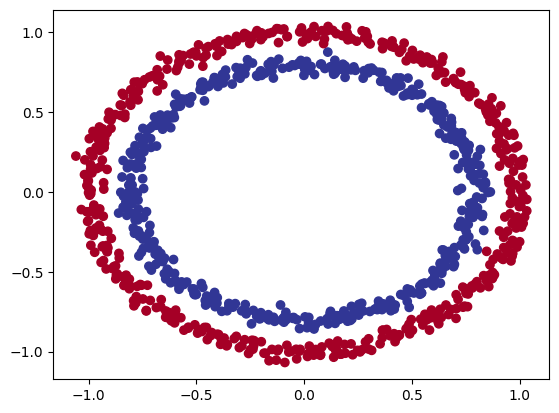

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);
plt.legend(handles=[plt.scatter([], [], marker='o', color='r'),
                    plt.scatter([], [], marker='o', color='b')],
           labels=['Class 1', 'Class 0']); # Dodawanie legendy ręcznie



Zbudowujemy sieć neuronową PyTorch, aby klasyfikować kropki na czerwone (0) lub niebieskie (1).

> **Uwaga:** Ten zbiór danych jest często uważany za **problem zabawkowy (toy problem)** (problem, który jest używany do prób i testów) w uczeniu maszynowym.
>
> Ale reprezentuje on klucz główny klasyfikacji, masz jakiś rodzaj danych przedstawionych jako wartości liczbowe i chciałbyś zbudować model, który jest w stanie je klasyfikować, w naszym przypadku, rozdzielić je na kropki czerwone lub niebieskie.

### 1.1 Błąd kształtu
Jednym z najczęstszych błędów w uczeniu głębokim są błędy kształtu.

Niedopasowanie kształtów tensorów i operacji na tensorach spowoduje błędy w modelach.


In [ ]:
# Sprawdzamy kształty danych
X.shape, y.shape

((1000, 2), (1000,))



Wygląda na to, że mamy dopasowanie w pierwszym wymiarze każdego z nich.
Mamy 1000 X i 1000 y.
Ale jaki jest drugi wymiar na X?
Często pomocne jest przeglądanie wartości i kształtów pojedynczej próbki (cechy i etykiety).
Pomoże to zrozumieć, jakich kształtów danych wejściowych i wyjściowych można oczekiwać od modelu.

In [ ]:
# Podglądamy pierwszą instancję danych
X_sample = X[0]
y_sample = y[0]
print(f"Wartości dla jednej instancji X: {X_sample} i jednej y: {y_sample}")
print(f"Kształt  jednej instancji  X: {X_sample.shape} i jednej y: {y_sample.shape}")

Wartości dla jednej instancji X: [0.75424625 0.23148074] i jednej y: 1
Kształt  jednej instancji  X: (2,) i jednej y: ()


To mówi nam, że drugi wymiar dla `X` oznacza, że ma on dwie cechy (wektor), podczas gdy `y` ma pojedynczą cechę (skalar).

Mamy dwa wejścia dla jednego wyjścia.

### 1.2 Przekształcanie danych w tensory i tworzenie podziałów treningowych i testowych

Zbadaliśmy wejściowe i wyjściowe kształty naszych danych, teraz przygotujmy je do użycia z PyTorch i do modelowania.

W szczególności będziemy musieli:
1. Przekształcić nasze dane w tensory (obecnie nasze dane są w tablicach NumPy, a PyTorch preferuje pracę z tensorami PyTorch).
2. Podzielić nasze dane na zestawy treningowe i testowe (będziemy trenować model na zestawie treningowym, aby nauczyć się wzorców między `X` i `y`, a następnie ocenić te wyuczone wzorce na testowym zestawie danych).

In [ ]:
# Przekształcenie danych na tensory
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Podgląd pierwszych 5 obserwacji
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

Teraz nasze dane są w formacie tensora, podzielmy je na zestawy treningowe i testowe.

Aby to zrobić, użyjmy pomocnej funkcji [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) z Scikit-Learn.

Użyjemy `test_size=0.2` (80% trening, 20% test), a ponieważ podział odbywa się losowo w danych, użyjmy `random_state=42`, aby podział był powtarzalny.

In [ ]:
# Podział na zbiór uczący i testowy
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% uczenie
                                                    random_state=42) # dla powtarzalności

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

Mamy 800 próbek uczących i 200 testowych.

## 2. Tworzenie modelu

Mamy już gotowe dane, teraz nadszedł czas na zbudowanie modelu.

Podzielimy go na kilka części.

1. Konfiguracja kodu niezależnego od urządzenia (aby nasz model mógł działać na CPU lub GPU, jeśli jest dostępny).
2. Konstruowanie modelu poprzez podklasę `nn.Module`.
3. Zdefiniowanie funkcji straty i optymalizatora.
4. Zdefiniowanie miary dopasowania modelu do danych.
5. Utworzenie pętli treningowej.

Dobrą wiadomością jest to, że wszystkie powyższe kroki wykonaliśmy już w tydzień temu Ćw.2.

Z wyjątkiem tego, że teraz dostosujemy je tak, aby działały z zestawem danych klasyfikacyjnych.

Zacznijmy od zaimportowania PyTorch i `torch.nn`, a także skonfigurowania kodu niezależnego od urządzenia.

In [ ]:
# Import PyTorch
import torch
from torch import nn

# Diagnoza urządzenia
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Doskonale, teraz `device` jest skonfigurowane, możemy go używać do dowolnych danych lub modeli, które tworzymy, a PyTorch będzie obsługiwał je na CPU (domyślnie) lub GPU, jeśli jest dostępny.
Zbudujemy model.

Będziemy potrzebować modelu zdolnego do obsługi naszych danych `X` jako danych wejściowych i generowania czegoś w kształcie naszych danych `y` jako danych wyjściowych.

Innymi słowy, biorąc pod uwagę `X` (cechy), chcemy, aby nasz model przewidywał `y` (etykietę).

Ta konfiguracja, w której masz cechy i etykiety, jest określana jako **uczenie z nadzorem**. Ponieważ dane mówią modelowi, jakie powinny być dane wyjściowe, biorąc pod uwagę określone dane wejściowe.

Aby stworzyć taki model, musi on obsługiwać kształty wejściowe i wyjściowe `X` i `y`.

Kształty danych wejściowych i wyjściowych są ważne.



### 2.0 Budowa modelu

Stwórzmy klasę modelu, która:
1. Jest podklasą `nn.Module` (prawie wszystkie modele PyTorch są podklasami `nn.Module`).
2. Tworzy 3 warstwy `nn.Linear` w konstruktorze zdolnym do obsługi kształtów wejściowych i wyjściowych `X` i `y`.
3. Definiuje metodę `forward()` zawierającą obliczenia przejścia do przodu modelu.
4. Instancjonuje klasę modelu i wysyła ją do docelowego `urządzenia`.

In [ ]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # extra layer
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x): # uwaga: zawsze upewnij się, że forward jest poprawnie napisany!
        # Tworzenie takiego modelu jest takie samo jak poniżej, choć poniżej
        # generalnie korzysta z przyspieszenia tam, gdzie to możliwe.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)



Liczba ukrytych neuronów, których można użyć w warstwach sieci neuronowej, jest **hiperparametrem** (wartością, którą można ustawić samodzielnie) i nie ma ustalonej wartości, której należy użyć.

Generalnie więcej znaczy lepiej, ale jest też coś takiego jak za dużo. Ilość, którą wybierzesz, będzie zależeć od typu modelu i zestawu danych, z którym pracujesz.

Ponieważ nasz zbiór danych jest mały i prosty, będziemy go utrzymywać na niskim poziomie.

Jedyną zasadą dotyczącą ukrytych neuronów jest to, że następna warstwa, w naszym przypadku `self.layer_2` musi przyjmować te same `in_features` co poprzednia warstwa `out_features`.

Dlatego `self.layer_2` ma `in_features=10`, pobiera `out_features=10` z `self.layer_1` i wykonuje na nich obliczenia liniowe, zamieniając je w `out_features=10.

*Wizualny przykład tego, jak wygląda sieć neuronowa podobna do tej, którą właśnie zbudowaliśmy. Spróbuj stworzyć własną na stronie [TensorFlow Playground website](https://playground.tensorflow.org/).*.

Możesz również zrobić to samo, co powyżej, używając [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html).

`nn.Sequential` wykonuje obliczenia w przód danych wejściowych przez warstwy w kolejności, w jakiej się pojawiają.

### 2.1 Konfiguracja funkcji straty i optymalizatora

Funkcję straty (zwaną również kryterium lub funkcją kosztu) i optymalizator skonfigurowaliśmy już wcześniej w [notebook 01](https://www.learnpytorch.io/01_pytorch_workflow/#creating-a-loss-function-and-optimizer-in-pytorch).

Jednak różne typy problemów wymagają różnych funkcji straty.

Na przykład, dla problemu regresji (przewidywanie liczby) można użyć średniego błędu bezwzględnego (MAE).

Z kolei w przypadku klasyfikacji binarnej (takiej jak nasza), jako funkcji straty często używa się [binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a).

Jednak ta sama funkcja optymalizatora może być często używana w różnych przestrzeniach problemowych.

Na przykład, optymalizator stochastycznego spadku gradientu (SGD, `torch.optim.SGD()`) może być użyty dla różnych problemów, to samo dotyczy optymalizatora Adam (`torch.optim.Adam()`).

| Funkcja straty/optymalizator | Typ problemu | Kod PyTorch |
| ----- | ----- | ----- |
| Stochastic Gradient Descent (SGD) optimizer | Klasyfikacja, regresja, wiele innych. | [`torch.optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) |
| Optymalizator Adama | Klasyfikacja, regresja, wiele innych. | [`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) |
| Binarna utrata entropii krzyżowej | Klasyfikacja binarna | [`torch.nn.BCELossWithLogits`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) lub [`torch.nn.BCELoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html) |
| Strata entropii krzyżowej | Klasyfikacja wieloklasowa | [`torch.nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) |
| Średni błąd bezwzględny (MAE) lub strata L1 | Regresja | [`torch.nn.L1Loss`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html) |
| Średni błąd kwadratowy (MSE) lub strata L2 | Regresja | [`torch.nn.MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#torch.nn.MSELoss) |  



Ponieważ pracujemy z problemem klasyfikacji binarnej, użyjmy binarnej funkcji straty entropii krzyżowej.

> **Uwaga**: Przypomnijmy, że **funkcja straty** jest tym, co mierzy, jak *błędne* są przewidywania modelu, im wyższa strata, tym gorszy model.
>
> Ponadto dokumentacja PyTorch często odnosi się do funkcji strat jako „kryterium strat” lub „kryterium”, są to różne sposoby opisywania tego samego.

PyTorch ma dwie binarne implementacje entropii krzyżowej:
1. [`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html) - tworzy funkcję straty, która mierzy binarną entropię krzyżową między celem (etykietą) a danymi wejściowymi (cechami).
2. [`torch.nn.BCEWithLogitsLoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) - To jest to samo, co powyżej, z wyjątkiem tego, że ma wbudowaną warstwę sigmoidalną ([`nn.Sigmoid`](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html)) (zobaczymy, co to oznacza wkrótce).

Której z nich powinieneś użyć?

Dokumentacja dla [`torch.nn.BCEWithLogitsLoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) stwierdza, że jest on bardziej stabilny numerycznie niż użycie `torch.nn.BCELoss()` po warstwie `nn.Sigmoid`.
Wiedząc o tym, stwórzmy funkcję straty i optymalizator.

Dla optymalizatora użyjemy `torch.optim.SGD()` do optymalizacji parametrów modelu z stałą uczenia 0.1.

> **Uwaga:** Na forach PyTorch toczy się [dyskusja na temat użycia `nn.BCELoss` vs. `nn.BCEWithLogitsLoss`](https://discuss.pytorch.org/t/bceloss-vs-bcewithlogitsloss/33586/4). Na początku może to być mylące, ale jak w przypadku wielu rzeczy, staje się łatwiejsze z praktyką.

In [ ]:
# Funkcja straty
# loss_fn = nn.BCELoss() # BCELoss = bez wbudowanej sigmoidalnej
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = z sigmoidalną

# Optymalizator
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

### 2.2 Miara oceny modelu **evaluation metric**.

Jeśli funkcja straty mierzy, jak *błędny* jest twój model, lubię myśleć o metrykach oceny jako o mierzeniu, jak *prawidłowy* jest.

Oczywiście można argumentować, że obie te metody robią to samo, ale wskaźniki oceny oferują inną perspektywę.

W końcu podczas oceny modeli dobrze jest spojrzeć na rzeczy z wielu punktów widzenia.

Istnieje kilka miar ewaluacyjnych, które mogą być stosowane w przypadku problemów z klasyfikacją, ale zacznijmy od **dokładności**.

Dokładność można zmierzyć dzieląc całkowitą liczbę poprawnych przewidywań przez całkowitą liczbę przewidywań.

Na przykład, model, który dokonuje 99 poprawnych predykcji na 100, będzie miał dokładność 99%.


In [ ]:
# Obliczenie dokładności modelu
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

### 2.3. Uczenie modelu - kroki


Kroki:

<details>
    <summary>Kroki pętli uczenia w PyTorch/podsumowanie>
    <ol>
        <li><b>Propagacja w przód</b> - Model przechodzi przez wszystkie dane treningowe
            <code>forward()</code>  (<code>model(x_train)</code>).
        </li>
        <li><b>Obliczenie straty</b> - Dane wyjściowe modelu (prognozy) są porównywane z prawdą i oceniane
            aby zobaczyć, jak
            są błędne (<code>loss = loss_fn(y_pred, y_train</code>).</li>
        <li><b>Zerowanie gradientów</b> - Gradienty optymalizatorów są ustawione na zero (są one domyślnie akumulowane), dzięki czemu
            mogą być
            ponownie obliczone dla konkretnego etapu szkolenia (<code>optimizer.zero_grad()</code>).</li>
        <li><b>Propagacja wsteczna</b> - Oblicza gradient strat w odniesieniu do każdego parametru modelu
             z <code>requires_grad=True</code>). To jest <b>backpropagation</b>, stąd „wsteczna”
            (<code>loss.backward()</code>).</li>
        <li><b>Optymalizator (gradient descent)</b> - Zaktualizuj parametry za pomocą <code>requires_grad=True</code>
            względem straty
               (<code>optimizer.step()</code>).</li>
    </ol>
</details>



### 2.4 Przechodzenie od surowych wyników modelu do przewidywanych etykiet

 (logity -> prawdopodobieństwa przewidywań -> etykiety przewidywań)

Przed krokami pętli treningowej zobaczmy, co wychodzi z naszego modelu podczas przejścia do przodu (przejście do przodu jest definiowane przez metodę `forward()`).

Aby to zrobić, przekażmy modelowi pewne dane.

In [ ]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model_1(X_test.to(device))[:5]
y_logits

tensor([[-0.1231],
        [-0.2515],
        [ 0.0241],
        [-0.1641],
        [-0.2765]], grad_fn=<SliceBackward0>)

Ponieważ nasz model nie został nauczony, wyniki te są w zasadzie losowe.

Są one wynikami kroku `forward()`.


Wyniki modelu nazywamy często logitami [**logits**](https://datascience.stackexchange.com/a/31045).


Aby przekształcić surowe dane wyjściowe naszego modelu (logity) do takiej postaci, możemy użyć funkcji [sigmoid activation function](https://pytorch.org/docs/stable/generated/torch.sigmoid.html).


In [ ]:
# Logity zamieniamy na prawdopodobieństwa
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4693],
        [0.4374],
        [0.5060],
        [0.4591],
        [0.4313]], grad_fn=<SigmoidBackward0>)


Wyniki są w formie **prediction probabilities**  (`y_pred_probs`). Innymi słowy, wartości określają teraz, w jakim stopniu model uważa, że punkt danych należy do jednej lub drugiej klasy.
Zasada:
* If `y_pred_probs` >= 0.5, `y=1` (class 1)
* If `y_pred_probs` < 0.5, `y=0` (class 0)

Aby przekształcić nasze prawdopodobieństwa predykcji w etykiety predykcji, możemy zaokrąglić wyjścia funkcji aktywacji sigmoidalnej.

### 2.5 Wizualizacja granic decyzyjnych

Zaimportujemy gotową funkcję.

In [ ]:
import requests
from pathlib import Path

# Pobieranie funkcji z zewnętrznego źródła
if Path("helper_functions.py").is_file():
  print("helper_functions.py już istnieje, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("/content/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py już istnieje, skipping download


###2.6 Budowa pętli uczącej i testowanie

In [ ]:
torch.manual_seed(42)

epochs = 1000 #

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Zerowanie gradientów
    optimizer.zero_grad()

    # 4. Propagacja wsteczna
    loss.backward()

    # 5. Optymalizacja
    optimizer.step()

    ### Testowanie
    model_1.eval()
    with torch.inference_mode():
        # 1. Propagacja w przód
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Obliczenie straty i dokładności loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Wydruk wyników co 10 epok
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.70333, Accuracy: 45.75% | Test loss: 0.69752, Test acc: 49.00%
Epoch: 100 | Loss: 0.69310, Accuracy: 51.00% | Test loss: 0.69394, Test acc: 48.00%
Epoch: 200 | Loss: 0.69299, Accuracy: 51.25% | Test loss: 0.69459, Test acc: 47.50%
Epoch: 300 | Loss: 0.69298, Accuracy: 51.25% | Test loss: 0.69470, Test acc: 46.50%
Epoch: 400 | Loss: 0.69298, Accuracy: 51.50% | Test loss: 0.69470, Test acc: 45.50%
Epoch: 500 | Loss: 0.69298, Accuracy: 51.38% | Test loss: 0.69469, Test acc: 45.00%
Epoch: 600 | Loss: 0.69298, Accuracy: 51.25% | Test loss: 0.69469, Test acc: 45.00%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.12% | Test loss: 0.69468, Test acc: 45.50%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.12% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


Wyniki nie są zadawalające.

### 2.7 Wykres

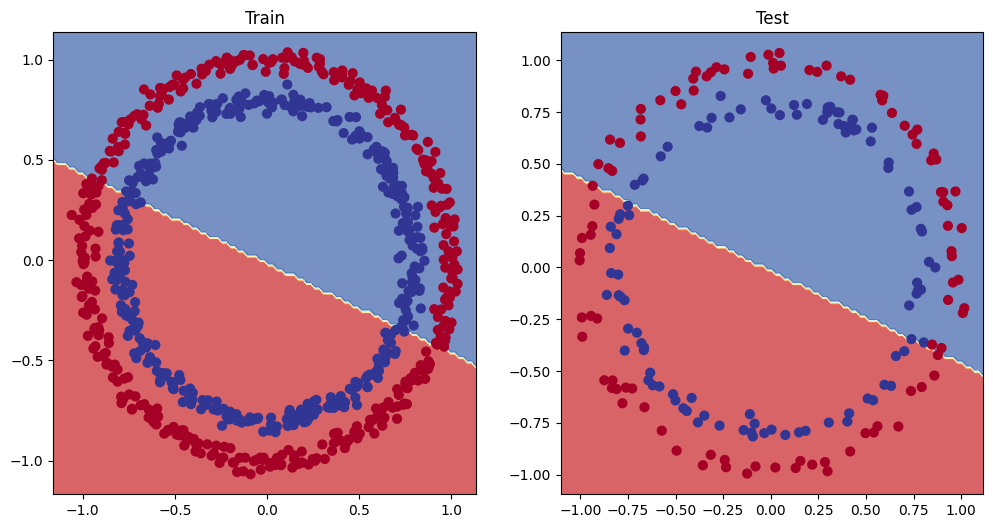

In [ ]:
# Narysujemy granice decyzyjne dla zestawów treningowych i testowych
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

Model działa kiepsko

## 3. Poprawa działania modelu


### 3.1 Odtwarzanie danych nieliniowych (czerwone i niebieskie kółka)

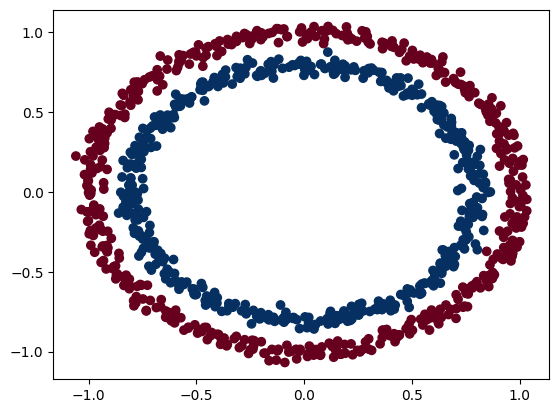

In [ ]:
# Wygenerowanie danych i wykres
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

In [ ]:
# Import bibliotek
import torch
from sklearn.model_selection import train_test_split

# Przekształcenie danych na tensory
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Podział danych
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 3.2 Budowanie modelu z nieliniowością. Funkcja aktywacji ReLu

Do tej pory nasze sieci neuronowe używały tylko liniowych (prostych) funkcji liniowych.

Ale dane, z którymi pracujemy są nieliniowe (okręgi).

Wprowadzimy do naszego modelu możliwość korzystania z **nieliniowych funkcji aktywacji**?

PyTorch ma kilka gotowych nieliniowych funkcji aktywacji [`zobacz tu`](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity), które robią podobne, ale różne rzeczy.
Jedną z najlepszych jest [`ReLU`](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)) (rectified linear-unit, [`torch.nn.ReLU()`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)).



* [TensorFlow Playground website](https://playground.tensorflow.org/).*

> **Pytanie:** Gdzie  umieścić nieliniowe funkcje aktywacji podczas konstruowania sieci neuronowej?
>
> Zasadą jest umieszczanie ich między warstwami ukrytymi i tuż za warstwą wyjściową, jednak nie ma ustalonej opcji. Gdy dowiesz się więcej o sieciach neuronowych i głębokim uczeniu, znajdziesz wiele różnych sposobów łączenia rzeczy. W międzyczasie najlepiej eksperymentować, eksperymentować, eksperymentować.


In [ ]:
# Budowa modelu z nieliniową funkcją aktywacji
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- dodanie ReLU jako funkcji aktywacji
        # można także użyć sigmoid

    def forward(self, x):
      # Przeplatanie funkcji aktywacji ReLU między warstwami
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


Teraz, gdy mamy już gotowy model, stwórzmy funkcję straty klasyfikacji binarnej, a także optymalizator.

In [ ]:
# Strata i optymalizator
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

### 3.3 Uczenie modelu z nieliniowością

Model, funkcja straty, optymalizator są dane. Twórzmy pętlę uczącą i testową.

In [ ]:
# Dopasowanie modelu
torch.manual_seed(42)
epochs = 1000

# Dane na urządzenie docelowe
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Przejści w przód
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits ->przewidywane prawdopodobieństwa -> prediction labels

    # 2. Strata i dokładność (accuracy)
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss oblicza stratę na logitach
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Zerowanie gradientów
    optimizer.zero_grad()

    # 4. Propagacja wsteczna
    loss.backward()

    # 5. Krok optymalizatora
    optimizer.step()

    ### Testowanie
    model_3.eval()
    with torch.inference_mode():
      # 1. Propagacja w przód
      test_logits = model_3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logity -> przewidywane prawdopodobieństwa -> przewidywane etykiety
      # 2. Obliczenie loss i accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Wydruk procesu uczenia
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.69319, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy: 52.88% | Test Loss: 0.69102, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977, Accuracy: 53.37% | Test Loss: 0.68940, Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy: 53.00% | Test Loss: 0.68723, Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy: 52.75% | Test Loss: 0.68411, Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy: 52.75% | Test Loss: 0.67941, Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy: 54.50% | Test Loss: 0.67285, Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659, Accuracy: 58.38% | Test Loss: 0.66322, Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160, Accuracy: 64.00% | Test Loss: 0.64757, Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy: 74.00% | Test Loss: 0.62145, Test Accuracy: 79.00%


### 3.4 Ocena modelu wytrenowanego z nieliniowymi funkcjami aktywacji

Dane naszego okręgu są nieliniowe. Zobaczmy, jak wyglądają przewidywania naszego modelu teraz, gdy model został wytrenowany z nieliniowymi funkcjami aktywacji.

In [ ]:
#Prognoza
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y[:10] #

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

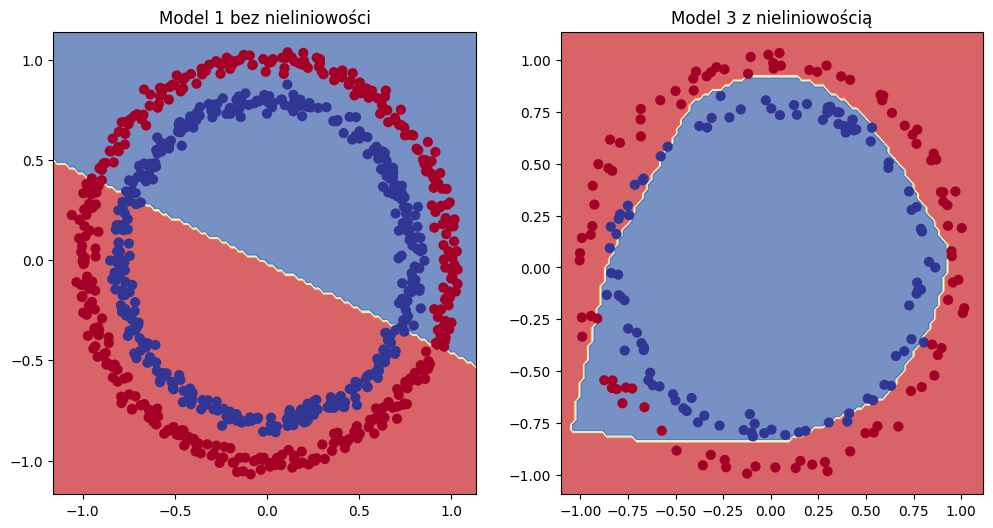

In [ ]:
# wykres
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Model 1 bez nieliniowości")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = bez nieliniowości
plt.subplot(1, 2, 2)
plt.title("Model 3 z nieliniowością")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = ma nieliniowość

## 4. Dodawanie nieliniowych funkcji aktywacji

Widzieliśmy wcześniej, jak dodanie nieliniowych funkcji aktywacji do naszego modelu może pomóc w modelowaniu danych nieliniowych.

> **Uwaga:** Wiele danych, które napotkasz w naturze, jest nieliniowych (lub stanowi kombinację liniowych i nieliniowych). W tej chwili pracowaliśmy z kropkami na wykresie 2D. Ale wyobraź sobie, że masz obrazy roślin, które chcesz sklasyfikować, istnieje wiele różnych kształtów roślin. Albo tekst z Wikipedii, który chciałbyś podsumować, istnieje wiele różnych sposobów łączenia słów (wzorce liniowe i nieliniowe).

Ale jak *wygląda* nieliniowa aktywacja?

A może odtworzymy niektóre z nich i to, co robią?

Zacznijmy od stworzenia niewielkiej ilości danych.

In [ ]:
# Utworzenie tensora
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

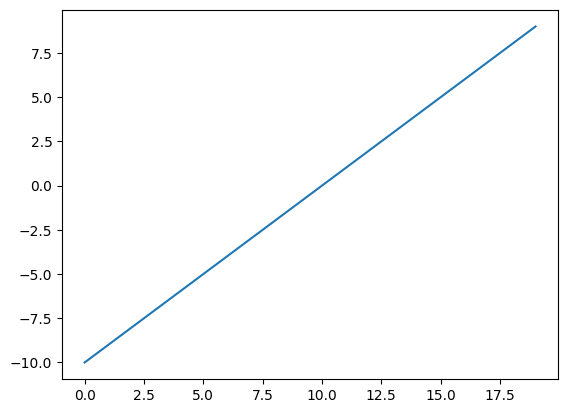

In [ ]:
# wykres
plt.plot(A);

Prosta. Zobaczymy co robi ReLu
 (`torch.nn.ReLU`)
Funkcja ReLU zamienia wszystkie wartości ujemne na 0 i pozostawia wartości dodatnie bez zmian.

In [ ]:
# Zdefiniowanie ReLu
def relu(x):
  return torch.maximum(torch.tensor(0), x) # inputs must be tensors

# Działanie ReLU na tensorze
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

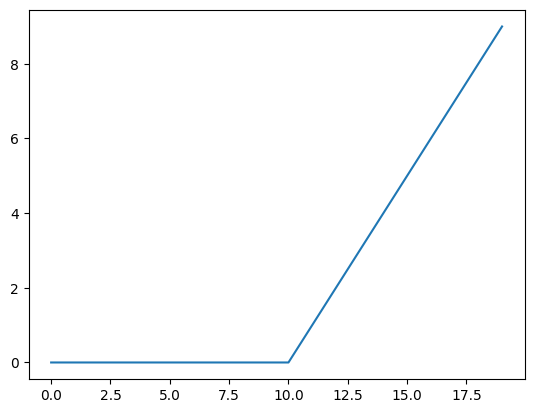

In [ ]:
# Wykres
plt.plot(relu(A));

Mamy wykres ReLU taki jak [Wikipedia page for ReLU](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)).

Wypróbujemy funkcję sigmoidalną [sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function).

Wzór funkcji sigmoidalnej:

$$ out_i = \frac{1}{1+e^{-input_i}} $$

Wykorzystując $x$ jako input:

$$ S(x) = \frac{1}{1+e^{-x_i}} $$

gdnie $S$ oznacza funkcję sigmoidalną, $e$ funkcję wykładniczą [exponential](https://en.wikipedia.org/wiki/Exponential_function) ([`torch.exp()`](https://pytorch.org/docs/stable/generated/torch.exp.html)) a $i$ oznacza wyraz tensora.


In [ ]:
# Zdefiniowanie funkcji sigmoidalnej
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

# sprawdzenie na tensorze
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

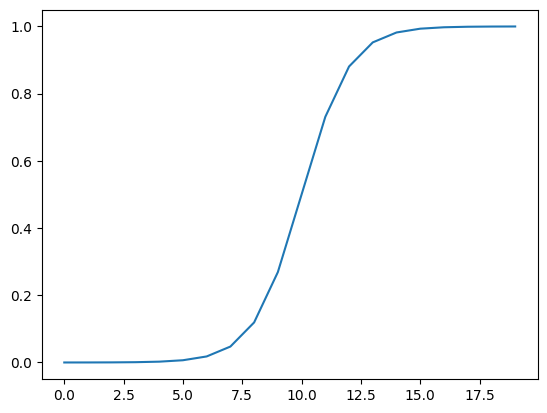

In [ ]:
# Wykres działania funkcji sigmoidalnej
plt.plot(sigmoid(A));

 [Nieliniowe funkcje aktywacji](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)

## 5. Budowa wieloklasowego modelu PyTorch

Problem klasyfikacji wieloklasowej

Przypomnijmy, że **klasyfikacja binarna** zajmuje się klasyfikacją czegoś jako jednej z dwóch opcji (np. zdjęcie jako zdjęcie kota lub zdjęcie psa), podczas gdy **klasyfikacja wieloklasowa** zajmuje się klasyfikacją czegoś z listy *więcej niż* dwóch opcji (np. klasyfikacja zdjęcia jako kota, psa lub kurczaka).

### 5.1 Utworzenie danych do klasyfikacji wieloklasowej

Aby to zrobić, możemy wykorzystać metodę Scikit-Learn [`make_blobs()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html).

Metoda ta utworzy dowolną liczbę klas (przy użyciu parametru `centers`).

W szczególności, wykonajmy następujące czynności:

1. Utwórz kilka danych wieloklasowych za pomocą `make_blobs()`.
2. Przekształć dane w tensory (domyślnie `make_blobs()` używa tablic NumPy).
3. Podziel dane na zestawy treningowe i testowe za pomocą funkcji `train_test_split()`.
4. Wizualizacja danych.

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


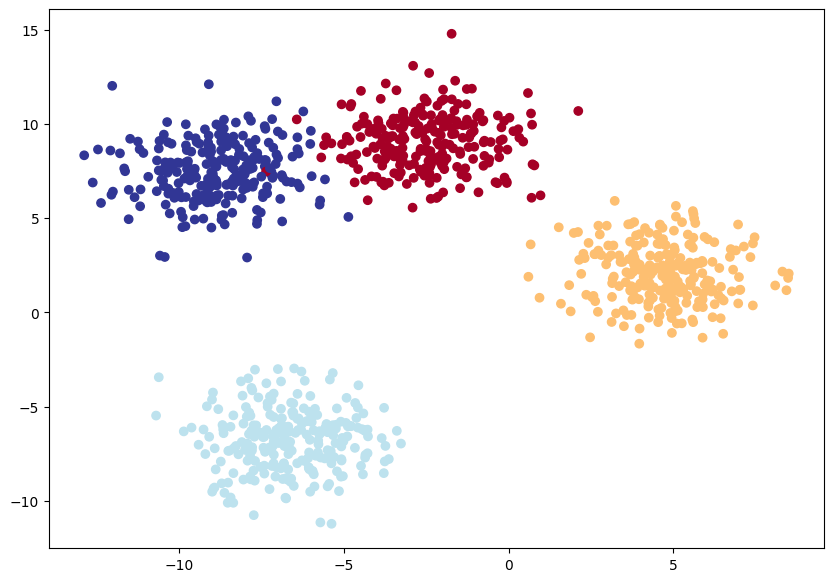

In [ ]:
# import bibilotek
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Zdefiniuj parametry (można zmienić, np dać 5 klas)
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Utworzenie danych
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X cechy
    centers=NUM_CLASSES, # y etykiety
    cluster_std=1.5, # lekko wstrząśnij klastrami (spróbuj zmienić wartość domyślną na 1,0)
    random_state=RANDOM_SEED
)

# 2. Dane na tensory
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Podział zbioru
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Wykres
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);



Zbudujmy model, aby oddzielić kolorowe plamy.

> **Pytanie:** Czy ten zbiór danych wymaga nieliniowości? Czy możesz narysować serię prostych linii, aby go oddzielić?

### 5.2 Tworzenie wieloklasowego modelu klasyfikacji w PyTorch

Do tej pory stworzyliśmy kilka modeli w PyTorch.

Być może zaczynasz już rozumieć, jak elastyczne są sieci neuronowe.

Co powiesz na zbudowanie modelu podobnego do `model_3`, ale nadal zdolnego do obsługi danych wieloklasowych?

Aby to zrobić, stwórzmy podklasę `nn.Module`, która przyjmuje trzy hiperparametry:
* `input_features` - liczba cech `X` wchodzących do modelu.
* `output_features` - idealna liczba cech wyjściowych (będzie to odpowiednik `NUM_CLASSES` lub liczby klas w twoim problemie klasyfikacji wieloklasowej).
* `hidden_units` - liczba ukrytych neuronów, których chcemy użyć w każdej ukrytej warstwie.

Skoro już łączymy wszystko razem, skonfigurujmy kod niezależny od urządzenia (nie musimy tego robić ponownie w tym samym notatniku, to tylko przypomnienie).

Następnie utworzymy klasę modelu przy użyciu powyższych hiperparametrów.

In [ ]:
# Sprawdzenie urządzenia
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
from torch import nn

# Budowa modelu
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        #Inicjuje wszystkie wymagane hiperparametry dla modelu klasyfikacji wieloklasowej.

                      #Argumenty:
                      #input_features (int): Liczba cech wejściowych modelu.
                     #out_features (int): Liczba cech wyjściowych modelu
                     # (ile jest klas).
                     #hidden_units (int): Liczba ukrytych jednostek między warstwami, domyślnie 8
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(), # <- przy nieliniowości
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(), # <- przy niliniowości
            nn.Linear(in_features=hidden_units, out_features=output_features), # liczba klas
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Budowa modelu BlobModel i przekazanie na urządzenie
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)


### 5.3 Tworzenie funkcji straty i optymalizatora dla wieloklasowego modelu PyTorch

Ponieważ pracujemy nad problemem klasyfikacji wieloklasowej, użyjemy metody `nn.CrossEntropyLoss()` jako naszej funkcji straty.

Do optymalizacji parametrów naszego `model_4` będziemy używać SGD ze współczynnikiem uczenia 0.1.

In [ ]:
# Strata i optymalizator
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1) # spróbuj zmienić

### 5.4 Uzyskiwanie prawdopodobieństwa predykcji dla wieloklasowego modelu PyTorch

W porządku, mamy gotową funkcję straty i optymalizator i jesteśmy gotowi do trenowania naszego modelu, ale zanim to zrobimy, wykonajmy pojedyncze przejście do przodu z naszym modelem, aby sprawdzić, czy działa.

In [ ]:
# Wykonaj pojedyncze przejście do przodu danych (aby zadziałało, będziemy musieli przesłać je do urządzenia docelowego)
model_4(X_blob_train.to(device))[:5]

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], grad_fn=<SliceBackward0>)

Co tu mamy? Chcemy mieć jedną wartość dla próbki.

In [ ]:
# Ile elementów znajduje się w pojedynczej próbce do predykcji?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [ ]:
# Tworzenie logitów
y_logits = model_4(X_blob_test.to(device))

# Zastosowanie softmax do logitów by uzyskać prawdopodobieństwa
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], grad_fn=<SliceBackward0>)
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], grad_fn=<SliceBackward0>)


Po przepuszczeniu logitów przez funkcję softmax, każda pojedyncza próbka daje sumę o wartości 1 (lub bardzo zbliżonej do niej).

In [ ]:
# Suma pierwszej próbki wyjściowej funkcji aktywacji softmax
torch.sum(y_pred_probs[0])

tensor(1., grad_fn=<SumBackward0>)

Te prawdopodobieństwa przewidywań zasadniczo mówią, jak bardzo model *sądzi*, że próbka docelowa `X` (dane wejściowe) mapuje się na każdą klasę.

Ponieważ w `y_pred_probs` istnieje jedna wartość dla każdej klasy, indeks *najwyższej* wartości jest klasą, do której model uważa, że ​​konkretna próbka danych *najbardziej* należy.

Możemy sprawdzić, który indeks daje najwiekszą wartość korzystając z `torch.argmax()`.

In [ ]:
# Która klasa jest według modelu *najbardziej* prawdopodobna w próbce o indeksie 0?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.1872, 0.2918, 0.1495, 0.3715], grad_fn=<SelectBackward0>)
tensor(3)


Możesz zobaczyć, że wynik `torch.argmax()` zwraca 3, więc dla cech (`X`) próbki o indeksie 0, model przewiduje, że najbardziej prawdopodobna wartość klasy (`y`) wynosi 3.

Oczywiście, w tej chwili jest to tylko losowe zgadywanie, więc prawdopodobieństwo jest 25% (ponieważ są cztery klasy). Ale możemy zwiększyć te szanse, trenując model.

> **Uwaga:** Podsumowując powyższe, surowy wynik modelu jest nazywany **logits**.
>
> W przypadku problemu klasyfikacji wieloklasowej, aby przekształcić logity w **prawdopodobieństwo predykcji**, należy użyć funkcji aktywacji softmax (`torch.softmax`).
>
> Indeks wartości o najwyższym **prawdopodobieństwie predykcji** to numer klasy, który model uważa za *najbardziej* prawdopodobny, biorąc pod uwagę cechy wejściowe dla tej próbki (chociaż jest to predykcja, nie oznacza to, że będzie poprawna).

### 5.5 Tworzenie pętli treningowej i testowej dla wieloklasowego modelu PyTorch

W porządku, teraz mamy już wszystkie kroki przygotowawcze za sobą, napiszmy pętlę treningową i testową, aby ulepszyć i ocenić nasz model.

Wiele z tych kroków wykonaliśmy już wcześniej, więc będzie to w dużej mierze praktyka.

Jedyną różnicą jest to, że będziemy dostosowywać kroki, aby przekształcić wyjścia modelu (logity) w prawdopodobieństwa predykcji (przy użyciu funkcji aktywacji softmax), a następnie w etykiety predykcji (biorąc argmax wyjścia funkcji aktywacji softmax).

Wytrenujmy model dla `epochs=100` i oceniajmy go co 10 epok.

In [ ]:
# Wybierz ziarno
torch.manual_seed(42)

# Ustal liczbę epok
epochs = 100

# Przenieś dane na urządzenie
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Uczenie
    model_4.train()

    # 1. Propagacja w przód
    y_logits = model_4(X_blob_train) # wyrzuca logity
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # przejście z logitów ->  prawdopodobieństwa -> przewidywane etykiety
    # print(y_logits)
    # 2. Strata i dokładność
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Wyzarowanie gradientów
    optimizer.zero_grad()

    # 4. Propadacja wsteczna
    loss.backward()

    # 5. Optymalizator
    optimizer.step()

    ### Testowanie
    model_4.eval()
    with torch.inference_mode():
      # 1. Propagacja w przód
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Strata i dokładność
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Wydruk
    if epoch % 10 == 0:
        print(f"Epoka: {epoch} | Strata: {loss:.5f}, Acc: {acc:.2f}% | Strata testowa: {test_loss:.5f}, Acc: {test_acc:.2f}%")

Epoka: 0 | Strata: 1.04324, Acc: 65.50% | Strata testowa: 0.57861, Acc: 95.50%
Epoka: 10 | Strata: 0.14398, Acc: 99.12% | Strata testowa: 0.13037, Acc: 99.00%
Epoka: 20 | Strata: 0.08062, Acc: 99.12% | Strata testowa: 0.07216, Acc: 99.50%
Epoka: 30 | Strata: 0.05924, Acc: 99.12% | Strata testowa: 0.05133, Acc: 99.50%
Epoka: 40 | Strata: 0.04892, Acc: 99.00% | Strata testowa: 0.04098, Acc: 99.50%
Epoka: 50 | Strata: 0.04295, Acc: 99.00% | Strata testowa: 0.03486, Acc: 99.50%
Epoka: 60 | Strata: 0.03910, Acc: 99.00% | Strata testowa: 0.03083, Acc: 99.50%
Epoka: 70 | Strata: 0.03643, Acc: 99.00% | Strata testowa: 0.02799, Acc: 99.50%
Epoka: 80 | Strata: 0.03448, Acc: 99.00% | Strata testowa: 0.02587, Acc: 99.50%
Epoka: 90 | Strata: 0.03300, Acc: 99.12% | Strata testowa: 0.02423, Acc: 99.50%


Model działa bardzo dobrze.

### 5.6 Tworzenie i ocena prognoz za pomocą modelu wieloklasowego PyTorch

Wygląda na to, że nasz wytrenowany model działa całkiem dobrze.

Ale aby się tego upewnić, zróbmy kilka prognoz i zwizualizujmy je.

In [ ]:
# Wyliczenie predykcji
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# Podgląd 10 pierwszych predykcji
y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0727,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2891],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5310,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]])

Przewidywania naszego modelu są nadal w formie logit.

Aby je ocenić, muszą być w tej samej formie co nasze etykiety (`y_blob_test`), które są w formie liczb całkowitych.

Przekształćmy logity przewidywań naszego modelu w prawdopodobieństwa przewidywań (używając `torch.softmax()`), a następnie w etykiety przewidywań (pobierając `argmax()` każdej próbki).

> **Uwaga:** Można pominąć funkcję `torch.softmax()` i przejść bezpośrednio z `predicted logits -> predicted labels`, wywołując `torch.argmax()` bezpośrednio na logitach.
>
> Na przykład `y_preds = torch.argmax(y_logits, dim=1)`, co oszczędza krok obliczeniowy (brak `torch.softmax()`), ale powoduje, że nie są dostępne żadne prawdopodobieństwa przewidywań.

In [ ]:
# Zamiana logitów w prawdopodobieństwa
y_pred_probs = torch.softmax(y_logits, dim=1)

# Zamiana prawdopodobieństw na etykiety
y_preds = y_pred_probs.argmax(dim=1)

# Porównanie pierwszych 10 preds i test labels
print(f"Przewidywania: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Dokładność: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Przewidywania: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Dokładność: 99.5%


Nasze prognozy modelu mają teraz taką samą formę jak nasze etykiety testowe.

Zwizualizujmy je za pomocą `plot_decision_boundary()`, pamiętajmy, że ponieważ nasze dane znajdują się na GPU, będziemy musieli przenieść je do CPU w celu użycia z matplotlib (`plot_decision_boundary()` robi to automatycznie za nas).

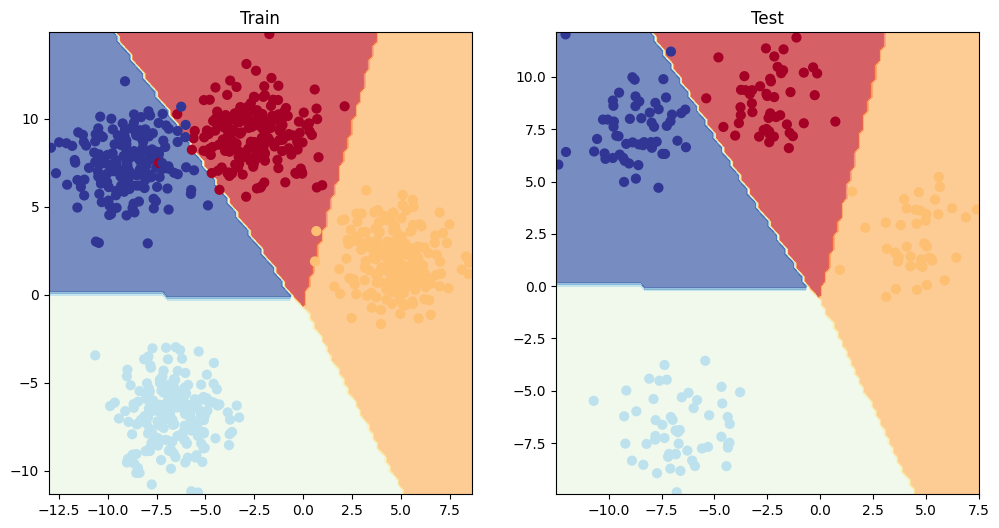

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 6. Więcej miar oceny klasyfikacji

Do tej pory omówiliśmy tylko kilka sposobów oceny modelu klasyfikacji (dokładność, straty i wizualizacja prognoz).

Są to jedne z najczęściej spotykanych metod i stanowią dobry punkt wyjścia.

Możesz jednak chcieć ocenić swój model klasyfikacji za pomocą większej liczby wskaźników, takich jak poniższe:

| **Nazwa miernika/Metoda oceny** | **Definicja** | **Kod** |
| --- | --- | --- |
| Dokładność/Trafność | Na 100 przewidywań, ile z nich jest poprawnych? Np. 95% dokładność oznacza, że 95/100 prognoz jest poprawnych. | [`torchmetrics.Accuracy()`](https://torchmetrics.readthedocs.io/en/stable/classification/accuracy.html#id3) lub [`sklearn.metrics.accuracy_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) |
| Precyzja | Odsetek wyników prawdziwie pozytywnych w stosunku do całkowitej liczby próbek. Wyższa precyzja prowadzi do mniejszej liczby fałszywych alarmów (model przewiduje 1, gdy powinien wynosić 0). | [`torchmetrics.Precision()`](https://torchmetrics.readthedocs.io/en/stable/classification/precision.html#id4) lub [`sklearn.metrics.precision_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html) |
|Recall| Odsetek wyników prawdziwie pozytywnych w stosunku do całkowitej liczby wyników prawdziwie pozytywnych i fałszywie negatywnych (model przewiduje 0, gdy powinno być 1). Wyższy recall prowadzi do mniejszej liczby fałszywych negatywów. | [`torchmetrics.Recall()`](https://torchmetrics.readthedocs.io/en/stable/classification/recall.html#id5) lub [`sklearn.metrics.recall_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) |
| F1-score | Łączy precyzję i wycofanie w jedną metrykę. 1 oznacza najlepszy wynik, 0 najgorszy. | [`torchmetrics.F1Score()`](https://torchmetrics.readthedocs.io/en/stable/classification/f1_score.html#f1score) lub [`sklearn.metrics|

Scikit-Learn (popularna i światowej klasy biblioteka uczenia maszynowego) ma wiele implementacji powyższych metryk, a jeśli szukasz wersji podobnej do PyTorch, sprawdź [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/), zwłaszcza sekcję klasyfikacji [TorchMetrics](https://torchmetrics.readthedocs.io/en/stable/pages/classification.html).

Wypróbujmy metrykę `torchmetrics.Accuracy`.




In [ ]:
try:
   from torchmetrics import Accuracy
except:
    !pip install torchmetrics==0.9.3 #  https://torchmetrics.readthedocs.io/en/stable/generated/CHANGELOG.html#changelog)
    from torchmetrics import Accuracy

# Skonfiguruj metrykę i upewnij się, że jest ona na urządzeniu docelowym
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Oblicz dokładność
torchmetrics_accuracy(y_preds, y_blob_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 937.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

tensor(0.9950)

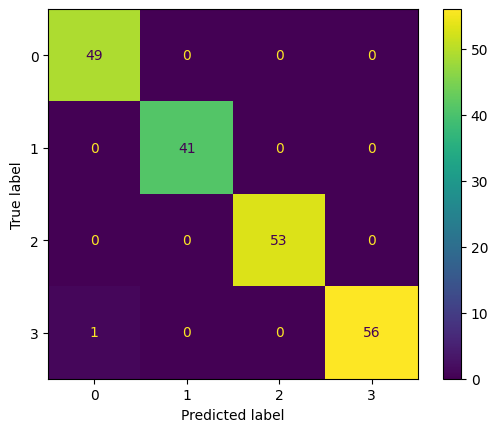

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
# Tworzenie macierzy pomyłek
cm = confusion_matrix(y_blob_test, y_preds)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_preds, y_blob_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        53
           3       0.98      1.00      0.99        56

    accuracy                           0.99       200
   macro avg       1.00      0.99      1.00       200
weighted avg       1.00      0.99      0.99       200

